# Basic Data Science
### A One-Day Intensive: 2–3 Hour Lesson + 4 Hours Hands-On
**Powered by Google Colaboratory**

The full arc: Python & NumPy foundations → data wrangling → EDA → statistics → your **first machine learning models** with scikit-learn. **Core libraries:** `numpy`, `pandas`, `matplotlib`, `seaborn`, `scikit-learn`, `re`, `requests`.

---
**How to use this notebook**
1. Run cells top to bottom (`Shift + Enter` runs a cell).
2. The **Setup** section generates all dummy datasets (CSV, TXT, Parquet, and a mock API JSON) — no uploads needed.
3. Lesson sections (Parts 1 onward) are the **2–3 hour instructor-led portion**.
4. The **Hands-On Lab** section at the end is the **4-hour guided exercise portion** with a capstone.

---
> © **Data Engineering Pilipinas (DEP). All rights reserved.**
> This course material was created by and is the property of Data Engineering Pilipinas. It may not be copied, distributed, modified, or used — in whole or in part — without prior written consent from Data Engineering Pilipinas.

## ⚙️ Setup — Generate the Dummy Datasets
Run the cell below **once** at the start of the session. It creates four practice datasets in a `data/` folder:

| File | Format | Simulates |
|---|---|---|
| `sales_data.csv` | CSV | Retail sales orders (intentionally *messy*: missing values, duplicates, mixed date formats, bad emails) |
| `server_logs.txt` | TXT | Raw web-server logs (for **regex** practice) |
| `transactions.parquet` | Parquet | Bank transactions (columnar format) |
| `customers_api.json` | JSON | A saved **API response** with customer records |

In [11]:
# =============================================================
# SETUP — Run this cell first! It generates all dummy datasets.
# Creates: sales_data.csv, server_logs.txt, transactions.parquet,
#          customers_api.json  (a saved mock API response)
# =============================================================
import pandas as pd
import numpy as np
import json, random, os

np.random.seed(42)
random.seed(42)
os.makedirs("data", exist_ok=True)

# ---------- 1. CSV: retail sales data (intentionally messy) ----------
n = 500
regions  = ["NCR", "Cebu", "Davao", "Iloilo", "Baguio"]
products = ["Rice 25kg", "Cooking Oil 1L", "Instant Coffee",
            "Laundry Soap", "Canned Sardines", "Sugar 1kg"]
dates = pd.date_range("2025-01-01", "2025-12-31", freq="D")

df = pd.DataFrame({
    "order_id":   [f"ORD-{i:05d}" for i in range(1, n + 1)],
    "order_date": np.random.choice(dates, n),
    "region":     np.random.choice(regions, n),
    "product":    np.random.choice(products, n),
    "quantity":   np.random.randint(1, 20, n),
    "unit_price": np.round(np.random.uniform(20, 1500, n), 2),
    "customer_email": [f"customer{i}@{random.choice(['gmail.com','yahoo.com','outlook.ph'])}" for i in range(n)],
    "phone":      [f"09{random.randint(100000000, 999999999)}" for _ in range(n)],
})
df["total_amount"] = (df["quantity"] * df["unit_price"]).round(2)

# Inject "messiness" so we can practice cleaning
dirty = df.copy()
dirty.loc[dirty.sample(25, random_state=1).index, "unit_price"] = np.nan
dirty.loc[dirty.sample(15, random_state=2).index, "region"] = " ncr "
dirty.loc[dirty.sample(10, random_state=3).index, "customer_email"] = "invalid-email"
dirty = pd.concat([dirty, dirty.sample(12, random_state=4)])   # duplicates
dirty["order_date"] = dirty["order_date"].astype(str)
mixed_idx = dirty.sample(20, random_state=5).index
dirty.loc[mixed_idx, "order_date"] = dirty.loc[mixed_idx, "order_date"].str.replace("-", "/")
dirty.to_csv("data/sales_data.csv", index=False)

# ---------- 2. TXT: server log file (for regex practice) ----------
levels    = ["INFO", "WARNING", "ERROR", "DEBUG"]
endpoints = ["/api/orders", "/api/customers", "/api/products", "/login", "/checkout"]
lines = []
for i in range(300):
    ts  = pd.Timestamp("2025-06-01") + pd.Timedelta(seconds=int(np.random.uniform(0, 86400 * 30)))
    lvl = random.choices(levels, weights=[60, 15, 10, 15])[0]
    ip  = f"{random.randint(1,255)}.{random.randint(0,255)}.{random.randint(0,255)}.{random.randint(1,254)}"
    ep  = random.choice(endpoints)
    ms  = random.randint(5, 2500)
    status = random.choices([200, 201, 404, 500, 403], weights=[70, 10, 8, 7, 5])[0]
    lines.append(f"{ts.strftime('%Y-%m-%d %H:%M:%S')} [{lvl}] client={ip} "
                 f"endpoint={ep} status={status} response_time={ms}ms")
with open("data/server_logs.txt", "w") as f:
    f.write("\n".join(sorted(lines)))

# ---------- 3. Parquet: bank-style transactions ----------
m = 800
tx = pd.DataFrame({
    "transaction_id":   [f"TXN{i:07d}" for i in range(1, m + 1)],
    "account_id":       [f"ACC{random.randint(1000,1099)}" for _ in range(m)],
    "transaction_type": np.random.choice(["deposit","withdrawal","transfer","payment"], m, p=[.3,.3,.2,.2]),
    "amount":           np.round(np.random.lognormal(mean=7, sigma=1.2, size=m), 2),
    "channel":          np.random.choice(["mobile_app","atm","branch","online"], m),
    "timestamp":        pd.to_datetime("2025-01-01") + pd.to_timedelta(np.random.uniform(0,365,m), unit="D"),
    "is_flagged":       np.random.choice([True, False], m, p=[.04,.96]),
})
tx.to_parquet("data/transactions.parquet", index=False)

# ---------- 4. Mock API response saved as JSON ----------
first = ["Maria","Jose","Juan","Ana","Carlo","Liza","Ramon","Grace","Paolo","Nina"]
last  = ["Santos","Reyes","Cruz","Garcia","Torres","Flores","Ramos","Mendoza"]
customers = []
for i in range(1, 61):
    fn, ln = random.choice(first), random.choice(last)
    customers.append({
        "customer_id": i,
        "name": f"{fn} {ln}",
        "email": f"{fn.lower()}.{ln.lower()}{i}@example.com",
        "city": random.choice(["Quezon City","Makati","Cebu City","Davao City","Taguig"]),
        "signup_date": str((pd.Timestamp("2024-01-01") + pd.Timedelta(days=random.randint(0,700))).date()),
        "loyalty_points": random.randint(0, 5000),
        "is_active": random.random() > 0.15,
    })
with open("data/customers_api.json", "w") as f:
    json.dump({"status": "success", "count": len(customers), "data": customers}, f, indent=2)

print("✅ Setup complete! Files created in ./data/:")
for fn in sorted(os.listdir("data")):
    print("   -", fn)

✅ Setup complete! Files created in ./data/:
   - .ipynb_checkpoints
   - api_users_raw.parquet
   - customers.csv
   - customers.parquet
   - customers_api.json
   - daily_summary.parquet
   - logs.parquet
   - sales_clean.csv
   - sales_clean.parquet
   - sales_data.csv
   - server_logs.txt
   - transactions.parquet
   - transactions_curated.parquet
   - tx_copy.csv
   - tx_copy.json


## Part 1 — Python Essentials (≈30 min)
Python is the *lingua franca* of data work. We only need a focused subset: **variables, collections, control flow, functions**, and the habit of writing small, reusable pieces of logic.

In [12]:
# Variables & data types
store_name = "DEP Sari-Sari Store"   # str
daily_sales = 15750.50               # float
num_customers = 42                   # int
is_open = True                       # bool

print(type(store_name), type(daily_sales), type(num_customers), type(is_open))
print(f"{store_name} earned ₱{daily_sales:,.2f} from {num_customers} customers today.")

<class 'str'> <class 'float'> <class 'int'> <class 'bool'>
DEP Sari-Sari Store earned ₱15,750.50 from 42 customers today.


In [13]:
# Collections: list, tuple, dict, set
products = ["rice", "oil", "coffee", "soap"]            # list  — ordered, mutable
location = (14.6760, 121.0437)                          # tuple — ordered, immutable (e.g., lat/lon)
prices   = {"rice": 52.0, "oil": 85.5, "coffee": 7.5}   # dict  — key/value lookup
regions  = {"NCR", "Cebu", "NCR", "Davao"}              # set   — unique values only

print("3rd product:", products[2])
print("Price of oil:", prices["oil"])
print("Unique regions:", regions)

3rd product: coffee
Price of oil: 85.5
Unique regions: {'NCR', 'Davao', 'Cebu'}


In [14]:
# Control flow: if / for / while
sales = [1200, 3400, 800, 5600, 2300]

total = 0
for amount in sales:
    total += amount
    if amount > 3000:
        print(f"  High-value sale: ₱{amount:,}")

print(f"Total: ₱{total:,}")
print(f"Average: ₱{total/len(sales):,.2f}")

# List comprehension — the "pythonic" one-liner loop
vat_inclusive = [round(s * 1.12, 2) for s in sales]
print("With 12% VAT:", vat_inclusive)

  High-value sale: ₱3,400
  High-value sale: ₱5,600
Total: ₱13,300
Average: ₱2,660.00
With 12% VAT: [1344.0, 3808.0, 896.0, 6272.0, 2576.0]


In [15]:
# Functions + error handling — the building blocks of reusable data code
def compute_discount(amount, customer_type="regular"):
    """Return the discounted amount based on customer type."""
    rates = {"regular": 0.0, "senior": 0.20, "pwd": 0.20, "member": 0.05}
    if customer_type not in rates:
        raise ValueError(f"Unknown customer type: {customer_type}")
    return round(amount * (1 - rates[customer_type]), 2)

print(compute_discount(1000))             # 1000.0
print(compute_discount(1000, "senior"))   # 800.0

# try/except keeps pipelines and analyses from crashing on bad input
try:
    compute_discount(1000, "vip")
except ValueError as e:
    print("Handled gracefully →", e)

1000.0
800.0
Handled gracefully → Unknown customer type: vip


## Part 2 — NumPy: Numerical Computing (≈20 min)
NumPy arrays are **fast, vectorized** containers — the foundation under pandas and scikit-learn. Rule of thumb: *if you're looping over numbers, there's probably a NumPy one-liner.*

In [16]:
import numpy as np

arr = np.array([1200, 3400, 800, 5600, 2300])

# Vectorized math — no loops!
print("With VAT:", arr * 1.12)
print("Mean:", arr.mean(), "| Std:", arr.std().round(2), "| Max:", arr.max())

# 2D arrays and slicing
matrix = np.arange(1, 13).reshape(3, 4)
print("\nMatrix:\n", matrix)
print("Row 0:", matrix[0])
print("Column 1:", matrix[:, 1])
print("Column sums:", matrix.sum(axis=0))

# Boolean masking — the pattern behind pandas filtering
big = arr[arr > 2000]
print("\nSales > 2000:", big)

With VAT: [1344. 3808.  896. 6272. 2576.]
Mean: 2660.0 | Std: 1726.96 | Max: 5600

Matrix:
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
Row 0: [1 2 3 4]
Column 1: [ 2  6 10]
Column sums: [15 18 21 24]

Sales > 2000: [3400 5600 2300]


## Loading Data from Every Source: CSV, TXT, Parquet & API (≈25 min)
Real projects pull data from many formats. Pandas gives you one interface: everything ends up as a **DataFrame**.

| Format | Best for | Reader |
|---|---|---|
| **CSV** | Universal exchange, spreadsheets | `pd.read_csv()` |
| **TXT** | Logs, raw text | `open()` + parsing (often regex) |
| **Parquet** | Big data, fast columnar analytics | `pd.read_parquet()` |
| **API (JSON)** | Live data from web services | `requests` + `pd.json_normalize()` |

In [17]:
import pandas as pd

# 1) CSV
sales = pd.read_csv("data/sales_data.csv")
print("CSV     →", sales.shape)

# 2) Parquet — note: column types are preserved (timestamps stay timestamps!)
tx = pd.read_parquet("data/transactions.parquet")
print("Parquet →", tx.shape, "| timestamp dtype:", tx["timestamp"].dtype)

# 3) TXT
with open("data/server_logs.txt") as f:
    log_lines = f.readlines()
print("TXT     →", len(log_lines), "log lines")

sales.head(3)

CSV     → (512, 9)
Parquet → (800, 7) | timestamp dtype: datetime64[ns]
TXT     → 300 log lines


,order_id,order_date,region,product,quantity,unit_price,customer_email,phone,total_amount
0,ORD-00001,2025-04-13,Cebu,Cooking Oil 1L,5,562.36,customer0@outlook.ph,9216066793,2811.80
1,ORD-00002,2025-12-15,ncr,Rice 25kg,16,606.34,customer1@gmail.com,9510751046,9701.44
2,ORD-00003,2025-09-28,Iloilo,Cooking Oil 1L,1,1049.29,customer2@gmail.com,9141580226,1049.29


In [18]:
# 4) API — the standard pattern with the `requests` library
import requests, json
import pandas as pd

# Real public API (needs internet). JSONPlaceholder is a free practice API.
try:
    resp = requests.get("https://jsonplaceholder.typicode.com/users", timeout=10)
    resp.raise_for_status()                      # error if status != 200
    users = pd.json_normalize(resp.json())      # nested JSON → flat table
    print("Live API call OK — status:", resp.status_code)
except Exception as e:
    print("No internet? Using the saved mock API response instead.", e)
    with open("data/customers_api.json") as f:
        users = pd.json_normalize(json.load(f)["data"])

users.head(3)

Live API call OK — status: 200


,id,name,username,email,phone,website,address.street,address.suite,address.city,address.zipcode,address.geo.lat,address.geo.lng,company.name,company.catchPhrase,company.bs
0,1,Leanne Graham,Bret,Sincere@april.biz,1-770-736-8031 x56442,hildegard.org,Kulas Light,Apt. 556,Gwenborough,92998-3874,-37.3159,81.1496,Romaguera-Crona,Multi-layered client-server neural-net,harness real-time e-markets
1,2,Ervin Howell,Antonette,Shanna@melissa.tv,010-692-6593 x09125,anastasia.net,Victor Plains,Suite 879,Wisokyburgh,90566-7771,-43.9509,-34.4618,Deckow-Crist,Proactive didactic contingency,synergize scalable supply-chains
2,3,Clementine Bauch,Samantha,Nathan@yesenia.net,1-463-123-4447,ramiro.info,Douglas Extension,Suite 847,McKenziehaven,59590-4157,-68.6102,-47.0653,Romaguera-Jacobson,Face to face bifurcated interface,e-enable strategic applications


In [19]:
# Our saved mock API response — same pattern, local file
import json
import pandas as pd

with open("data/customers_api.json") as f:
    payload = json.load(f)

print("status:", payload["status"], "| count:", payload["count"])
customers = pd.json_normalize(payload["data"])
customers.head()

status: success | count: 60


,customer_id,name,email,city,signup_date,loyalty_points,is_active
0,1,Carlo Mendoza,carlo.mendoza1@example.com,Quezon City,2024-08-21,1100,True
1,2,Grace Flores,grace.flores2@example.com,Cebu City,2025-03-02,4955,True
2,3,Ana Mendoza,ana.mendoza3@example.com,Makati,2025-02-20,3968,True
3,4,Liza Santos,liza.santos4@example.com,Taguig,2024-06-11,537,True
4,5,Paolo Ramos,paolo.ramos5@example.com,Makati,2025-06-20,4658,False


## Data Cleaning (≈25 min)
Analysts and engineers spend **50–80% of their time cleaning data**. The classic checklist:
1. **Missing values** → fill, drop, or flag
2. **Duplicates** → remove
3. **Inconsistent categories** → standardize (`" ncr "` vs `"NCR"`)
4. **Wrong data types** → convert (dates stored as text, numbers stored as strings)
5. **Invalid values** → detect with rules or regex

In [20]:
import pandas as pd
sales = pd.read_csv("data/sales_data.csv")

# --- Diagnose first ---
print("Shape:", sales.shape)
print("\nMissing values per column:")
print(sales.isna().sum())
print("\nDuplicate rows:", sales.duplicated().sum())
print("\nRegion values (note the messy ' ncr '):", sales["region"].unique())

Shape: (512, 9)

Missing values per column:
order_id           0
order_date         0
region             0
product            0
quantity           0
unit_price        26
customer_email     0
phone              0
total_amount       0
dtype: int64

Duplicate rows: 12

Region values (note the messy ' ncr '): <ArrowStringArray>
['Cebu', ' ncr ', 'Iloilo', 'Davao', 'NCR', 'Baguio']
Length: 6, dtype: str


In [21]:
# --- Clean step by step ---
clean = sales.copy()

# 1) Duplicates
clean = clean.drop_duplicates()

# 2) Standardize categories: strip spaces, uppercase
clean["region"] = clean["region"].str.strip().str.upper()

# 3) Missing unit_price → recover it from total_amount / quantity
mask = clean["unit_price"].isna()
clean.loc[mask, "unit_price"] = (clean.loc[mask, "total_amount"] / clean.loc[mask, "quantity"]).round(2)

# 4) Fix mixed date formats (2025-03-01 vs 2025/03/01) → real datetime
clean["order_date"] = pd.to_datetime(clean["order_date"], format="mixed")

# 5) Flag invalid emails with regex
clean["email_valid"] = clean["customer_email"].str.match(r"^[\w\.\-]+@[\w\-]+\.[\w\.]+$")

print("After cleaning:", clean.shape)
print("Missing:", clean.isna().sum().sum(), "| Duplicates:", clean.duplicated().sum())
print("Regions:", clean["region"].unique())
print("Invalid emails flagged:", (~clean["email_valid"]).sum())
clean.to_csv("data/sales_clean.csv", index=False)   # save for later sections
clean.head(3)

After cleaning: (500, 10)
Missing: 0 | Duplicates: 0
Regions: <ArrowStringArray>
['CEBU', 'NCR', 'ILOILO', 'DAVAO', 'BAGUIO']
Length: 5, dtype: str
Invalid emails flagged: 10


,order_id,order_date,region,product,quantity,unit_price,customer_email,phone,total_amount,email_valid
0,ORD-00001,2025-04-13,CEBU,Cooking Oil 1L,5,562.36,customer0@outlook.ph,9216066793,2811.80,True
1,ORD-00002,2025-12-15,NCR,Rice 25kg,16,606.34,customer1@gmail.com,9510751046,9701.44,True
2,ORD-00003,2025-09-28,ILOILO,Cooking Oil 1L,1,1049.29,customer2@gmail.com,9141580226,1049.29,True


## Regular Expressions (Regex) — Pattern Matching for Text (≈25 min)
Regex lets you **find, validate, and extract** patterns in text — emails, phone numbers, log entries, IDs. The `re` module is built into Python, and pandas has `.str.extract()` / `.str.contains()` built on top of it.

**Cheat sheet:**
| Pattern | Matches |
|---|---|
| `\d` | a digit (0–9) |
| `\w` | a word character (letter, digit, `_`) |
| `\s` | whitespace |
| `+` / `*` | one-or-more / zero-or-more |
| `{n,m}` | between *n* and *m* repeats |
| `[abc]` | any one of a, b, c |
| `^` / `$` | start / end of string |
| `( )` | capture group (extract this part) |

In [22]:
import re

# --- Extract structured fields from raw log lines ---
with open("data/server_logs.txt") as f:
    logs = f.readlines()

print("Raw log line:")
print(logs[0])

# One pattern, four capture groups: timestamp, level, status, response time
pattern = r"^([\d\-]+ [\d:]+) \[(\w+)\] client=([\d\.]+) endpoint=(\S+) status=(\d{3}) response_time=(\d+)ms"

m = re.match(pattern, logs[0])
print("\nParsed:", m.groups())

# Parse ALL lines into a DataFrame — regex turns unstructured text into a table!
import pandas as pd
parsed = [re.match(pattern, line).groups() for line in logs if re.match(pattern, line)]
log_df = pd.DataFrame(parsed, columns=["timestamp", "level", "client_ip", "endpoint", "status", "response_ms"])
log_df["response_ms"] = log_df["response_ms"].astype(int)
log_df["status"] = log_df["status"].astype(int)
log_df.head()

Raw log line:
2025-06-01 08:55:51 [ERROR] client=40.199.162.93 endpoint=/api/orders status=200 response_time=379ms


Parsed: ('2025-06-01 08:55:51', 'ERROR', '40.199.162.93', '/api/orders', '200', '379')


,timestamp,level,client_ip,endpoint,status,response_ms
0,2025-06-01 08:55:51,ERROR,40.199.162.93,/api/orders,200,379
1,2025-06-01 09:04:38,INFO,137.47.86.152,/checkout,200,636
2,2025-06-01 12:57:52,INFO,204.203.40.96,/login,200,1885
3,2025-06-01 15:42:46,INFO,21.168.194.245,/api/products,404,2003
4,2025-06-01 19:33:37,INFO,39.31.230.27,/api/products,200,350


In [23]:
# --- Validating & extracting with regex ---
import re

emails = ["nina@dep.org.ph", "invalid-email", "juan.cruz@gmail.com", "test@", "ana_reyes@yahoo.com"]
email_pattern = r"^[\w\.\-]+@[\w\-]+\.[\w\.]+$"

for e in emails:
    ok = "✅ valid" if re.match(email_pattern, e) else "❌ invalid"
    print(f"{e:30s} {ok}")

# Extract PH mobile numbers from free text
text = "Contact us at 09171234567 or 09989876543. Landline: 8123-4567."
print("\nMobile numbers found:", re.findall(r"09\d{9}", text))

# re.sub — find & replace (mask sensitive digits)
masked = re.sub(r"(09\d{2})\d{5}(\d{2})", r"\1*****\2", text)
print("Masked:", masked)

nina@dep.org.ph                ✅ valid
invalid-email                  ❌ invalid
juan.cruz@gmail.com            ✅ valid
test@                          ❌ invalid
ana_reyes@yahoo.com            ✅ valid

Mobile numbers found: ['09171234567', '09989876543']
Masked: Contact us at 0917*****67 or 0998*****43. Landline: 8123-4567.


In [24]:
# --- Regex inside pandas: clean a real column ---
import pandas as pd
sales = pd.read_csv("data/sales_data.csv")

# Flag invalid emails using .str.match()
valid = sales["customer_email"].str.match(r"^[\w\.\-]+@[\w\-]+\.[\w\.]+$")
print(f"Invalid emails found: {(~valid).sum()} out of {len(sales)} rows")
sales.loc[~valid, "customer_email"].head()

Invalid emails found: 10 out of 512 rows


27     invalid-email
37     invalid-email
130    invalid-email
191    invalid-email
211    invalid-email
Name: customer_email, dtype: str

## Basic Charts with Matplotlib & Seaborn (≈30 min)
**Choosing the right chart:**
| Question | Chart |
|---|---|
| Compare categories | **Bar** |
| Trend over time | **Line** |
| Distribution of one variable | **Histogram** |
| Relationship of two variables | **Scatter** |
| Correlations across many variables | **Heatmap** |
| Share of a whole (few categories) | **Pie** |

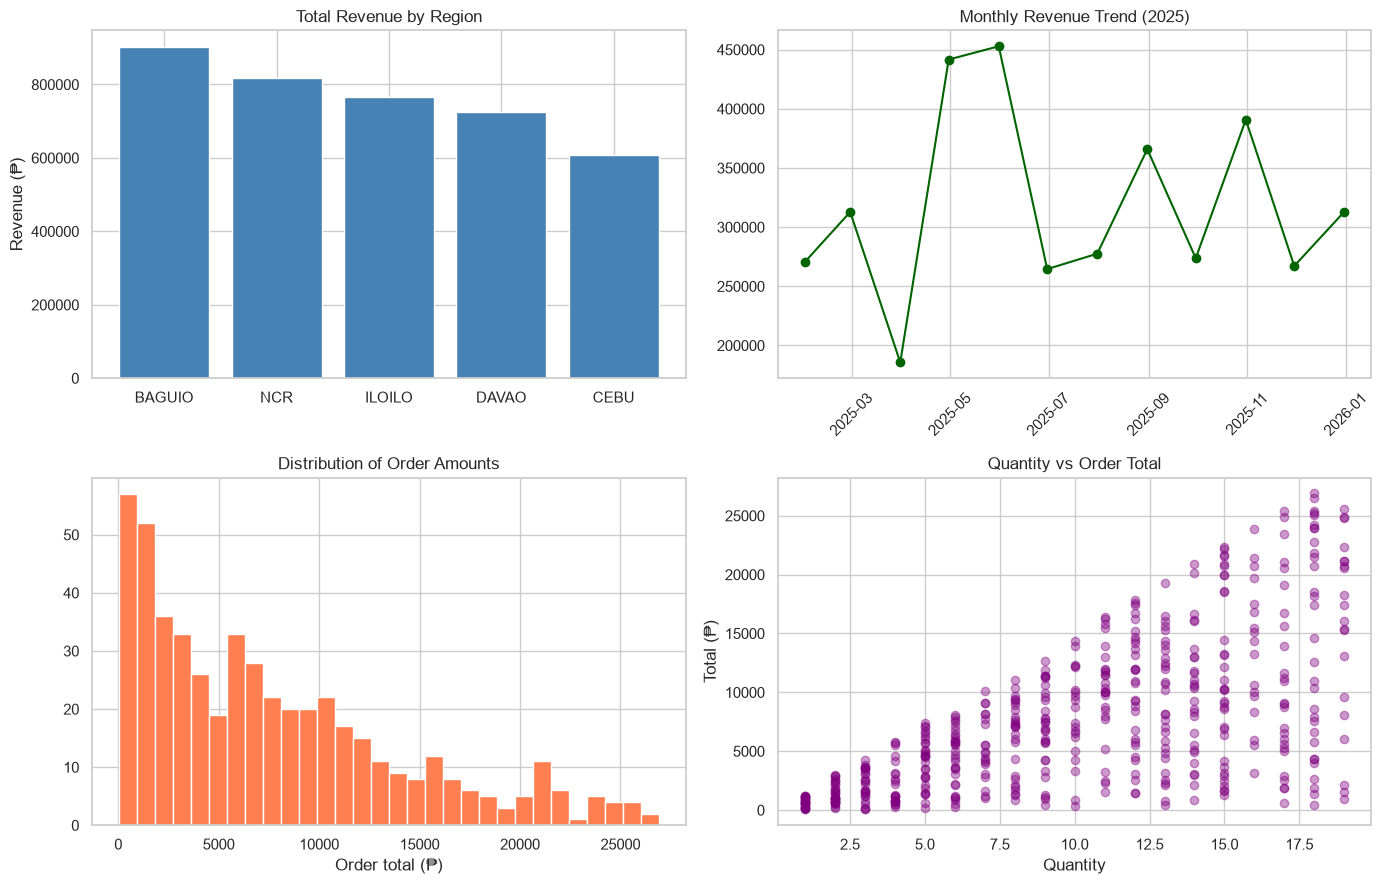

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sales = pd.read_csv("data/sales_clean.csv", parse_dates=["order_date"])
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1) BAR — revenue by region
by_region = sales.groupby("region")["total_amount"].sum().sort_values(ascending=False)
axes[0,0].bar(by_region.index, by_region.values, color="steelblue")
axes[0,0].set_title("Total Revenue by Region")
axes[0,0].set_ylabel("Revenue (₱)")

# 2) LINE — monthly revenue trend
monthly = sales.set_index("order_date").resample("ME")["total_amount"].sum()
axes[0,1].plot(monthly.index, monthly.values, marker="o", color="darkgreen")
axes[0,1].set_title("Monthly Revenue Trend (2025)")
axes[0,1].tick_params(axis="x", rotation=45)

# 3) HISTOGRAM — distribution of order values
axes[1,0].hist(sales["total_amount"], bins=30, color="coral", edgecolor="white")
axes[1,0].set_title("Distribution of Order Amounts")
axes[1,0].set_xlabel("Order total (₱)")

# 4) SCATTER — quantity vs total
axes[1,1].scatter(sales["quantity"], sales["total_amount"], alpha=0.4, color="purple")
axes[1,1].set_title("Quantity vs Order Total")
axes[1,1].set_xlabel("Quantity"); axes[1,1].set_ylabel("Total (₱)")

plt.tight_layout()
plt.show()

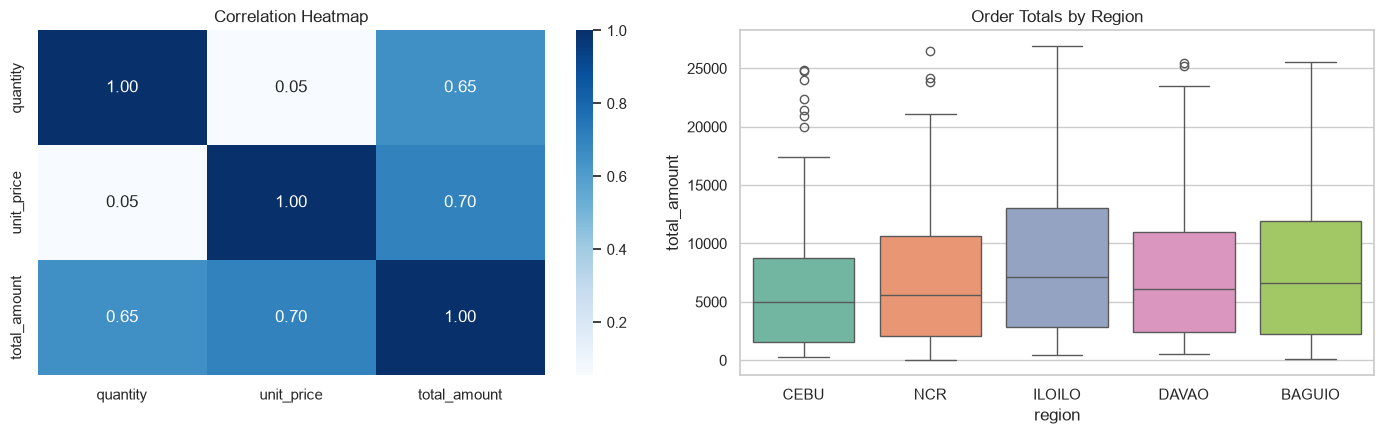

In [26]:
# Seaborn shines for statistical plots — heatmap + boxplot
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sales = pd.read_csv("data/sales_clean.csv", parse_dates=["order_date"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Correlation heatmap (numeric columns only)
corr = sales[["quantity", "unit_price", "total_amount"]].corr()
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f", ax=axes[0])
axes[0].set_title("Correlation Heatmap")

# Boxplot — order totals per region (spot outliers instantly)
sns.boxplot(data=sales, x="region", y="total_amount", ax=axes[1], hue="region", legend=False, palette="Set2")
axes[1].set_title("Order Totals by Region")

plt.tight_layout()
plt.show()

## Part 6 — Exploratory Data Analysis (EDA) Workflow (≈20 min)
EDA = systematically getting to know a dataset **before** modeling:
1. Shape, dtypes, missing values
2. Univariate: distribution of each variable
3. Bivariate: relationships between variables
4. Outliers & anomalies
5. Questions & hypotheses

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    800 non-null    str           
 1   account_id        800 non-null    str           
 2   transaction_type  800 non-null    str           
 3   amount            800 non-null    float64       
 4   channel           800 non-null    str           
 5   timestamp         800 non-null    datetime64[ns]
 6   is_flagged        800 non-null    bool          
dtypes: bool(1), datetime64[ns](1), float64(1), str(4)
memory usage: 62.8 KB
None

Missing: 0


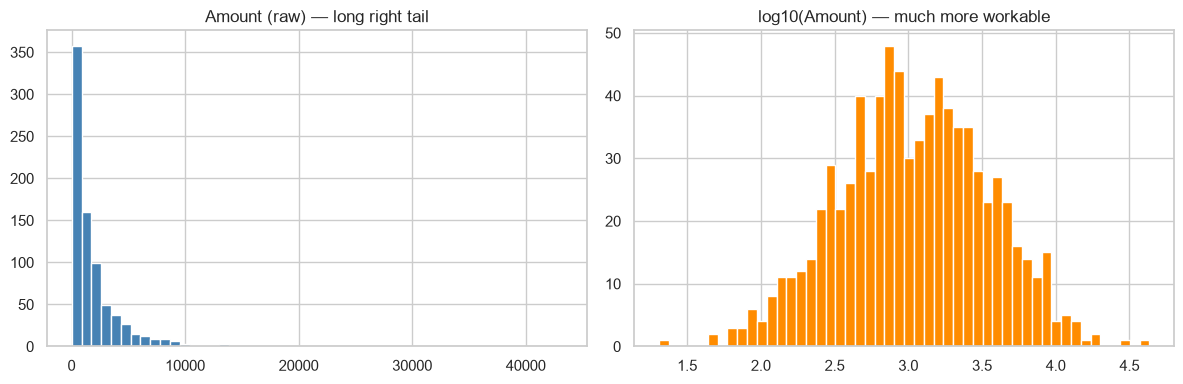

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

tx = pd.read_parquet("data/transactions.parquet")

# 1) Structure
print(tx.info())
print("\nMissing:", tx.isna().sum().sum())

# 2) Univariate — amount is heavily skewed (typical for money data)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(tx["amount"], bins=50, color="steelblue")
axes[0].set_title("Amount (raw) — long right tail")
import numpy as np
axes[1].hist(np.log10(tx["amount"]), bins=50, color="darkorange")
axes[1].set_title("log10(Amount) — much more workable")
plt.tight_layout(); plt.show()

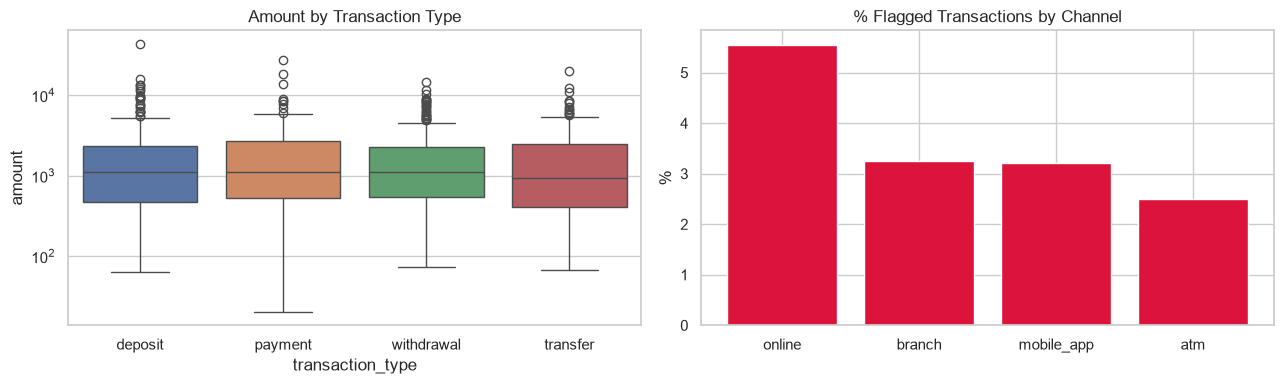

                  count     mean      std    min     25%      50%      75%  \
transaction_type                                                             
deposit           243.0  2223.58  3727.28  63.80  475.54  1097.22  2358.36   
payment           155.0  2142.35  3200.76  20.29  528.38  1099.07  2688.52   
transfer          166.0  1905.11  2537.73  66.90  412.46   940.63  2484.74   
withdrawal        236.0  1930.57  2249.74  73.86  535.61  1098.99  2269.32   

                       max  
transaction_type            
deposit           43232.01  
payment           27490.87  
transfer          19772.72  
withdrawal        14323.54  


In [28]:
# 3) Bivariate + categorical breakdowns
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

tx = pd.read_parquet("data/transactions.parquet")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=tx, x="transaction_type", y="amount", ax=axes[0], hue="transaction_type", legend=False)
axes[0].set_yscale("log"); axes[0].set_title("Amount by Transaction Type")

flag_rate = tx.groupby("channel")["is_flagged"].mean().sort_values(ascending=False)
axes[1].bar(flag_rate.index, flag_rate.values * 100, color="crimson")
axes[1].set_title("% Flagged Transactions by Channel"); axes[1].set_ylabel("%")
plt.tight_layout(); plt.show()

print(tx.groupby("transaction_type")["amount"].describe().round(2))

## Part 7 — Statistics & Probability Essentials (≈20 min)
- **Descriptive** stats summarize what happened; **inferential** stats generalize beyond the sample.
- The **normal distribution** and the 68–95–99.7 rule.
- **Correlation ≠ causation** — the most important sentence in data science.

Within ±1σ: 68.4% (theory: 68.3%)
Within ±2σ: 95.5% (theory: 95.4%)


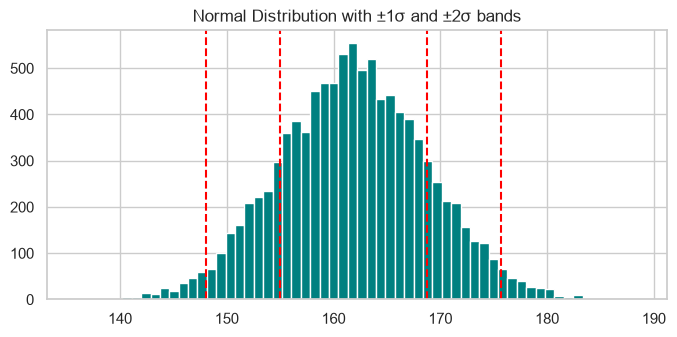

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate the normal distribution + the empirical rule
np.random.seed(0)
heights = np.random.normal(loc=162, scale=7, size=10_000)   # PH adult heights, cm (illustrative)

mu, sigma = heights.mean(), heights.std()
within_1sd = ((heights > mu - sigma) & (heights < mu + sigma)).mean()
within_2sd = ((heights > mu - 2*sigma) & (heights < mu + 2*sigma)).mean()
print(f"Within ±1σ: {within_1sd:.1%} (theory: 68.3%)")
print(f"Within ±2σ: {within_2sd:.1%} (theory: 95.4%)")

plt.figure(figsize=(8, 3.5))
plt.hist(heights, bins=60, color="teal", edgecolor="white")
for k in (1, 2):
    plt.axvline(mu - k*sigma, color="red", ls="--"); plt.axvline(mu + k*sigma, color="red", ls="--")
plt.title("Normal Distribution with ±1σ and ±2σ bands")
plt.show()

In [30]:
# Correlation vs causation demo
import pandas as pd
import numpy as np

sales = pd.read_csv("data/sales_clean.csv")
print("Correlation matrix:")
print(sales[["quantity", "unit_price", "total_amount"]].corr().round(3))
print("""
quantity ↔ total_amount correlate strongly — quantity CAUSES higher totals (total = qty × price).
But in the wild, correlation alone never proves causation:
ice cream sales correlate with drowning incidents... because SUMMER causes both. 🌞""")

Correlation matrix:
              quantity  unit_price  total_amount
quantity         1.000       0.055         0.650
unit_price       0.055       1.000         0.702
total_amount     0.650       0.702         1.000

quantity ↔ total_amount correlate strongly — quantity CAUSES higher totals (total = qty × price).
But in the wild, correlation alone never proves causation:
ice cream sales correlate with drowning incidents... because SUMMER causes both. 🌞


## Part 8 — First Machine Learning Models with scikit-learn (≈40 min)
The universal scikit-learn recipe:
```
1. X (features) and y (target)
2. train_test_split
3. model.fit(X_train, y_train)
4. model.predict(X_test)
5. evaluate
```
We'll do one **regression** (predict a number) and one **classification** (predict a category).

In [31]:
# REGRESSION — predict order total from quantity & unit price
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

sales = pd.read_csv("data/sales_clean.csv")
X = sales[["quantity", "unit_price"]]
y = sales["total_amount"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)

print("R² score:", round(r2_score(y_test, pred), 3))
print("Mean Abs Error: ₱", round(mean_absolute_error(y_test, pred), 2))
print("Coefficients:", dict(zip(X.columns, model.coef_.round(2))))

R² score: 0.872
Mean Abs Error: ₱ 1777.21
Coefficients: {'quantity': np.float64(726.76), 'unit_price': np.float64(10.43)}


In [32]:
# CLASSIFICATION — predict whether a transaction gets flagged
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

tx = pd.read_parquet("data/transactions.parquet")

# Feature engineering: encode categoricals as dummy variables
feats = pd.get_dummies(tx[["amount", "transaction_type", "channel"]],
                       columns=["transaction_type", "channel"])
target = tx["is_flagged"]

X_train, X_test, y_train, y_test = train_test_split(
    feats, target, test_size=0.25, random_state=42, stratify=target)

clf = LogisticRegression(max_iter=2000, class_weight="balanced")
clf.fit(X_train, y_train)
pred = clf.predict(X_test)

print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred, digits=3))
print("⚠️ Note the class imbalance (only ~4% flagged) — accuracy alone would be misleading!")

[[107  86]
 [  4   3]]
              precision    recall  f1-score   support

       False      0.964     0.554     0.704       193
        True      0.034     0.429     0.062         7

    accuracy                          0.550       200
   macro avg      0.499     0.491     0.383       200
weighted avg      0.931     0.550     0.681       200

⚠️ Note the class imbalance (only ~4% flagged) — accuracy alone would be misleading!


---
# 🧪 HANDS-ON LAB (4 hours)

### Block A — NumPy & Wrangling Warm-up (⭐ 45 min)
1. Create a NumPy array of 1,000 random daily sales (`np.random.normal(50000, 12000, 1000)`); compute mean, median, std, and the % of days above ₱60,000.
2. Load the transactions Parquet; what share of total amount moves through the **mobile_app** channel?
3. From `sales_clean.csv`, use regex to extract email domains and find the top 3.

In [33]:
# Block A — your code here
import numpy as np
import pandas as pd
sales = pd.read_csv("data/sales_clean.csv")

np.random.seed(42)
daily_sales = np.random.normal(loc=50000,scale=12000,size=1000)
mean = np.mean(daily_sales)
median = np.median(daily_sales)
std = np.std(daily_sales)
percent_above_60000 = np.mean(daily_sales > 60000) * 100

print("\n")
print("Daily Sales")
print(f"Mean: {mean:,.2f}")
print(f"Median: {median:,.2f}")
print(f"Standard Deviation: {std:,.2f}")
print(f"Days above ₱60,000: {percent_above_60000:.2f}%")
print("\n")

transactions = pd.read_parquet("data/transactions.parquet")
total_amount = transactions["amount"].sum()
mobile_app_amount = transactions.loc[transactions["channel"] == "mobile_app","amount"].sum()
mobile_app_share = (mobile_app_amount / total_amount) * 100


print(f"Total transaction amount: ₱{total_amount:,.2f}")
print(f"Mobile app transaction amount: ₱{mobile_app_amount:,.2f}")
print(f"Share through mobile_app: {mobile_app_share:.2f}%")
print("\n")

sales["email_domain"] = sales["customer_email"].str.extract(r"@([\w.-]+)$",expand=False)
top3_domains = sales["email_domain"].value_counts().head(3)


print("Top 3 Email Domains")
print(top3_domains)
print("\n")




Daily Sales
Mean: 50,231.98
Median: 50,303.61
Standard Deviation: 11,744.71
Days above ₱60,000: 19.00%


Total transaction amount: ₱1,644,255.79
Mobile app transaction amount: ₱403,790.48
Share through mobile_app: 24.56%


Top 3 Email Domains
email_domain
gmail.com     182
outlook.ph    167
yahoo.com     141
Name: count, dtype: int64




### Block B — Full EDA (⭐⭐ 75 min)
Perform a complete EDA on `data/transactions.parquet`:
1. Structure + missing values check
2. At least 4 charts (distribution, category comparison, time trend via `timestamp`, and one of your choice)
3. IQR outlier detection on `amount`
4. Write 3 bullet-point findings in a markdown cell.

First 5 rows


,transaction_id,account_id,transaction_type,amount,channel,timestamp,is_flagged
0,TXN0000001,ACC1014,deposit,388.59,mobile_app,2025-07-28 03:42:48.899833128,False
1,TXN0000002,ACC1030,payment,8387.23,atm,2025-03-18 16:32:20.435683925,False
2,TXN0000003,ACC1063,withdrawal,1155.79,atm,2025-09-28 22:17:50.626068118,False
3,TXN0000004,ACC1081,withdrawal,806.73,branch,2025-01-10 04:44:38.654277250,False
4,TXN0000005,ACC1076,deposit,740.60,mobile_app,2025-05-10 12:19:37.396409180,False



Dataset Shape
Rows: 800
Columns: 7

Column Names
['transaction_id', 'account_id', 'transaction_type', 'amount', 'channel', 'timestamp', 'is_flagged']

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    800 non-null    str           
 1   account_id        800 non-null    str           
 2   transaction_type  800 non-null    str           
 3   amount            800 non-null    float64       
 4   channel           800 non-null    str           
 5   timestamp         800 non-null    datetime64[ns]
 6   is_flagged        800 non-null    bool          
dtypes: bool(1), datetime64[ns](1), float64(1), str(4)
memory usage: 62.8 KB

Missing Values


,Missing_Count,Missing_Percentage
transaction_id,0,0.0
account_id,0,0.0
transaction_type,0,0.0
amount,0,0.0
channel,0,0.0
timestamp,0,0.0
is_flagged,0,0.0



Duplicate rows: 0


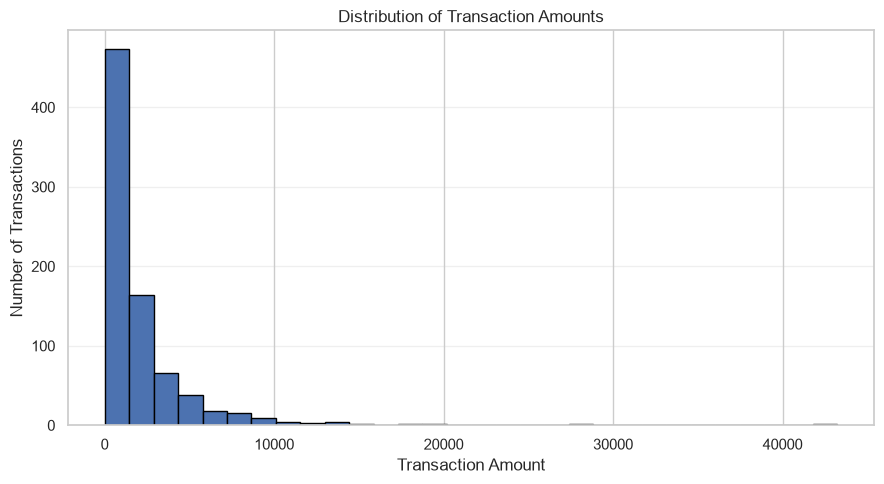

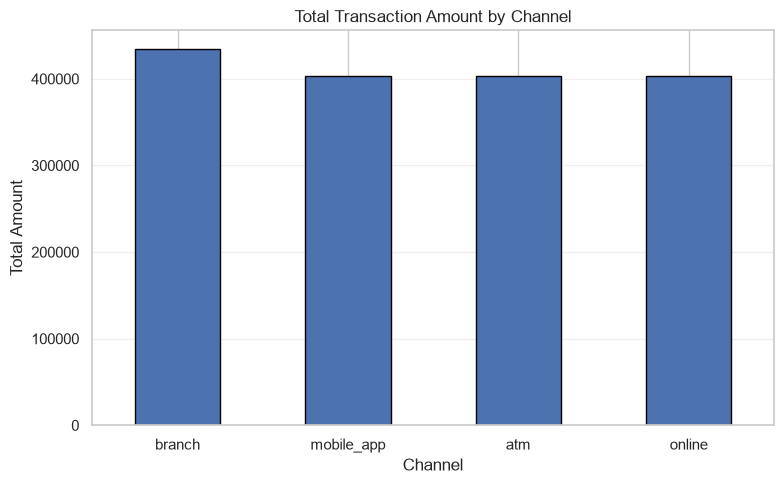

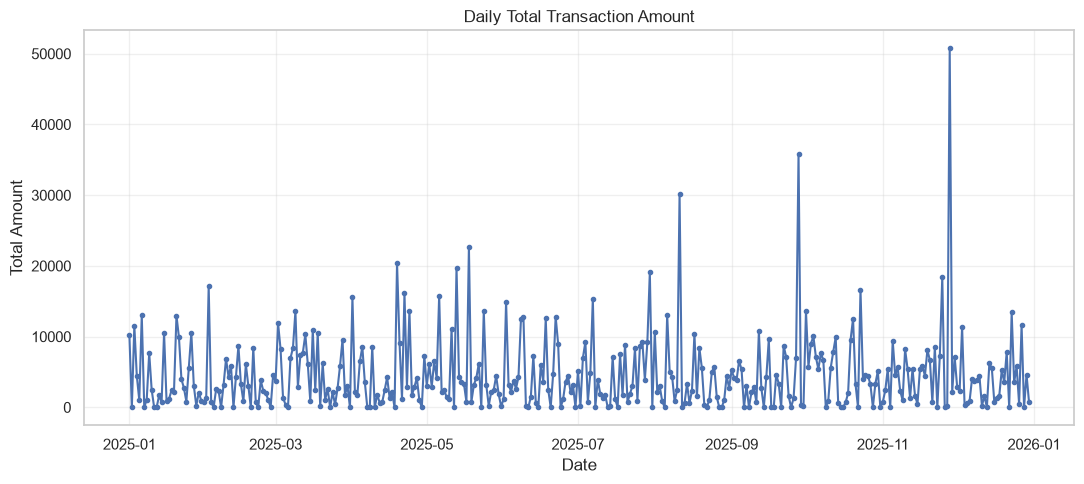

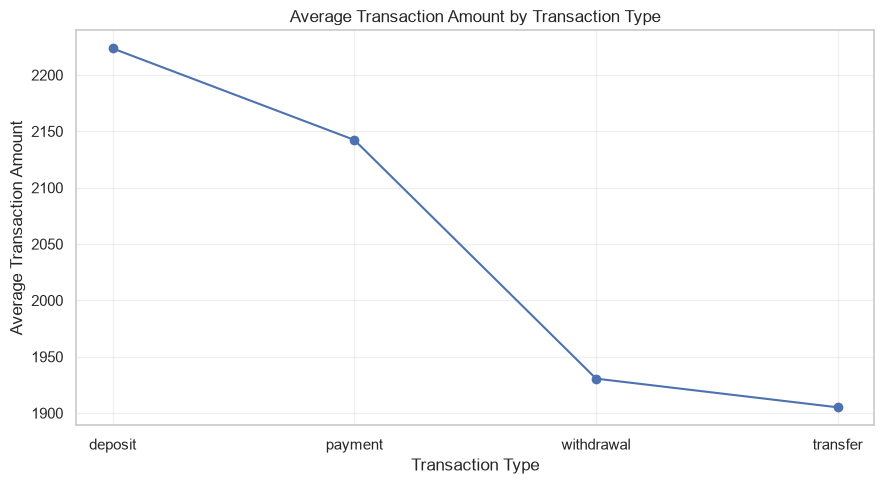


Number of Outliers: 69
Outlier Percentage: 8.62%


In [38]:
# Block B — your code here
import pandas as pd
import matplotlib.pyplot as plt

transactions = pd.read_parquet("data/transactions.parquet")

print("First 5 rows")
display(transactions.head())

print("\nDataset Shape")
print(f"Rows: {transactions.shape[0]}")
print(f"Columns: {transactions.shape[1]}")

print("\nColumn Names")
print(transactions.columns.tolist())

print("\nDataset Information")
transactions.info()

missingValues = pd.DataFrame({
    "Missing_Count": transactions.isnull().sum(),
    "Missing_Percentage": (
        transactions.isnull().mean() * 100
    ).round(2)
})

print("\nMissing Values")
display(missingValues)

duplicate_count = transactions.duplicated().sum()

print(f"\nDuplicate rows: {duplicate_count}")

transactions["timestamp"] = pd.to_datetime(transactions["timestamp"],errors="coerce")
eda_data = transactions.dropna(subset=["timestamp", "amount"]).copy()

plt.figure(figsize=(9, 5))

plt.hist(eda_data["amount"],bins=30,edgecolor="black")

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


amount_by_channel = (eda_data.groupby("channel")["amount"].sum().sort_values(ascending=False))

plt.figure(figsize=(8, 5))

amount_by_channel.plot(kind="bar",edgecolor="black")

plt.title("Total Transaction Amount by Channel")
plt.xlabel("Channel")
plt.ylabel("Total Amount")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

daily_amount = (eda_data.set_index("timestamp").resample("D")["amount"].sum())

plt.figure(figsize=(11, 5))

plt.plot(
    daily_amount.index,
    daily_amount.values,
    marker="o",
    markersize=3
)

plt.title("Daily Total Transaction Amount")
plt.xlabel("Date")
plt.ylabel("Total Amount")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

average_amount_type = (eda_data.groupby("transaction_type")["amount"].mean().sort_values(ascending=False))

plt.figure(figsize=(9, 5))

plt.plot(
    average_amount_type.index,
    average_amount_type.values,
    marker="o"
)

plt.title("Average Transaction Amount by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Average Transaction Amount")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Q1 = eda_data["amount"].quantile(0.25)
Q3 = eda_data["amount"].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - (1.5 * IQR)
upper_limit = Q3 + (1.5 * IQR)

outliers = eda_data[(eda_data["amount"] < lower_limit)| (eda_data["amount"] > upper_limit)]

print(f"\nNumber of Outliers: {len(outliers)}")
print( f"Outlier Percentage: {len(outliers) / len(eda_data) * 100:.2f}%")

Findings

-Most transactions have low to medium amounts.
-The mobile_app channel handles about 24.56% of the total amount.
-Daily transaction totals go up and down with no clear trend.

### Block C — Modeling (⭐⭐⭐ 75 min)
1. Improve the flagged-transaction classifier: add an `hour` feature from `timestamp`, try a `DecisionTreeClassifier`, and compare classification reports.
2. Regression: predict `loyalty_points` from the customers API data using any features you engineer. Report R² honestly — even if it's bad, explain *why*.
3. Bonus: use `train_test_split` with different `random_state` values — how stable are your metrics?

In [35]:
# Block C — your code here
import json
import pandas as pd
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report,
    r2_score,
    mean_absolute_error,
    f1_score
)

transactions = pd.read_parquet("data/transactions.parquet")

transactions["timestamp"] = pd.to_datetime(transactions["timestamp"])
transactions["hour"] = transactions["timestamp"].dt.hour

features = transactions[
    ["amount", "hour", "transaction_type", "channel"]
]

target = transactions["is_flagged"].astype(int)

features = pd.get_dummies(
    features,
    columns=["transaction_type", "channel"],
    drop_first=True,
    dtype=int
)

features_train, features_test, target_train, target_test = train_test_split(
    features,
    target,
    test_size=0.20,
    random_state=42,
    stratify=target
)

scaler = StandardScaler()

features_train_scaled = scaler.fit_transform(features_train)
features_test_scaled = scaler.transform(features_test)

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

logistic_model.fit(features_train_scaled, target_train)

logistic_predictions = logistic_model.predict(
    features_test_scaled
)

print("Logistic Regression")
print(
    classification_report(
        target_test,
        logistic_predictions,
        target_names=["Not Flagged", "Flagged"],
        zero_division=0
    )
)

tree_model = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

tree_model.fit(features_train, target_train)

tree_predictions = tree_model.predict(features_test)

print("Decision Tree")
print(
    classification_report(
        target_test,
        tree_predictions,
        target_names=["Not Flagged", "Flagged"],
        zero_division=0
    )
)


with open("data/customers_api.json") as file:
    customers = pd.json_normalize(json.load(file)["data"])

customers["signup_date"] = pd.to_datetime(customers["signup_date"])

customers["days_since_signup"] = (
    customers["signup_date"].max() - customers["signup_date"]
).dt.days

customers["is_active"] = customers["is_active"].astype(int)

loyalty_features = pd.get_dummies(
    customers[["city", "days_since_signup", "is_active"]],
    columns=["city"],
    drop_first=True,
    dtype=int
)

loyalty_target = customers["loyalty_points"]

features_train, features_test, target_train, target_test = train_test_split(
    loyalty_features,
    loyalty_target,
    test_size=0.20,
    random_state=42
)

regression = LinearRegression()
regression.fit(features_train, target_train)

predictions = regression.predict(features_test)

print("Regression Result")
print(f"R²: {r2_score(target_test, predictions):.3f}")
print(
    f"MAE: {mean_absolute_error(target_test, predictions):,.2f} points"
)

results = []

for state in [0, 1, 2, 3, 4, 42]:

    ft_train, ft_test, tt_train, tt_test = train_test_split(
        features,
        target,
        test_size=0.20,
        random_state=state,
        stratify=target
    )

    tree = DecisionTreeClassifier(
        max_depth=5,
        class_weight="balanced",
        random_state=state
    )

    tree.fit(ft_train, tt_train)

    tree_f1 = f1_score(
        tt_test,
        tree.predict(ft_test),
        zero_division=0
    )

    fr_train, fr_test, tr_train, tr_test = train_test_split(
        loyalty_features,
        loyalty_target,
        test_size=0.20,
        random_state=state
    )

    regression = LinearRegression()
    regression.fit(fr_train, tr_train)

    regression_r2 = r2_score(
        tr_test,
        regression.predict(fr_test)
    )

    results.append({
        "Random State": state,
        "Tree Flagged F1": round(tree_f1, 3),
        "Regression R²": round(regression_r2, 3)
    })

stability_results = pd.DataFrame(results)

print("\nMetric Stability")
display(stability_results)

print("\nStandard Deviation")
print(
    stability_results[
        ["Tree Flagged F1", "Regression R²"]
    ].std().round(3)
)

Logistic Regression
              precision    recall  f1-score   support

 Not Flagged       0.97      0.47      0.64       154
     Flagged       0.05      0.67      0.09         6

    accuracy                           0.48       160
   macro avg       0.51      0.57      0.36       160
weighted avg       0.94      0.48      0.62       160

Decision Tree
              precision    recall  f1-score   support

 Not Flagged       0.96      0.57      0.72       154
     Flagged       0.03      0.33      0.05         6

    accuracy                           0.56       160
   macro avg       0.49      0.45      0.38       160
weighted avg       0.92      0.56      0.69       160

Regression Result
R²: -0.314
MAE: 1,405.81 points

Metric Stability


,Random State,Tree Flagged F1,Regression R²
0,0,0.000,0.046
1,1,0.065,-0.323
2,2,0.000,-0.335
3,3,0.081,-0.403
4,4,0.000,-0.178
5,42,0.054,-0.314



Standard Deviation
Tree Flagged F1    0.038
Regression R²      0.163
dtype: float64


### Block D — Mini-Capstone (⭐⭐⭐ 45 min)
**Scenario:** The bank asks: *"Can we predict flagged transactions well enough to prioritize manual review?"*
Deliver: a short markdown recommendation (go / no-go), your best model's metrics, the single most important caveat, and one chart summarizing performance.

Model Performance


,Model,Precision,Recall,F1 Score,Accuracy
0,Logistic Regression,0.047,0.667,0.088,0.481
1,Decision Tree,0.029,0.333,0.054,0.562



Best Model: Logistic Regression
Precision: 0.047
Recall: 0.667
F1 Score: 0.088
Accuracy: 0.481


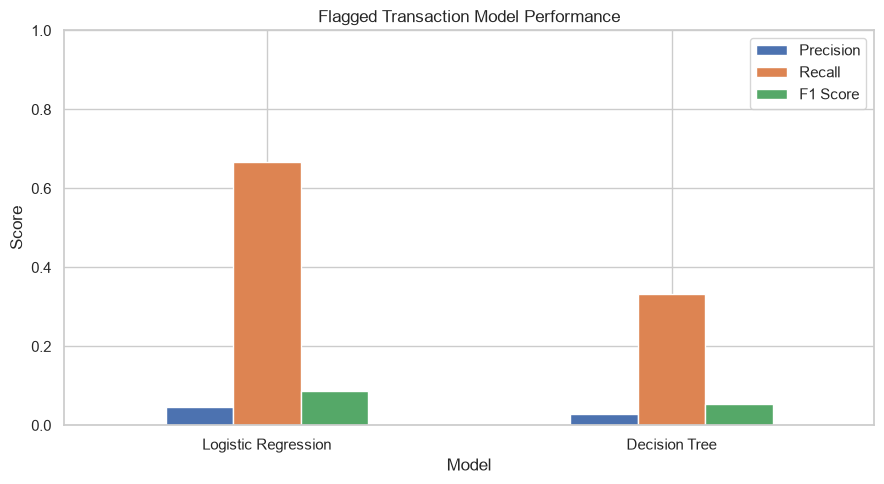

In [36]:
# Block D — your capstone here
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

transactions = pd.read_parquet("data/transactions.parquet")

transactions["timestamp"] = pd.to_datetime(transactions["timestamp"])
transactions["hour"] = transactions["timestamp"].dt.hour

features = transactions[
    ["amount", "hour", "transaction_type", "channel"]
]

target = transactions["is_flagged"].astype(int)

features = pd.get_dummies(
    features,
    columns=["transaction_type", "channel"],
    drop_first=True,
    dtype=int
)

features_train, features_test, target_train, target_test = train_test_split(
    features,
    target,
    test_size=0.20,
    random_state=42,
    stratify=target
)

scaler = StandardScaler()

features_train_scaled = scaler.fit_transform(features_train)
features_test_scaled = scaler.transform(features_test)

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

logistic_model.fit(features_train_scaled, target_train)

logistic_predictions = logistic_model.predict(
    features_test_scaled
)

tree_model = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

tree_model.fit(features_train, target_train)

tree_predictions = tree_model.predict(features_test)

logistic_report = classification_report(
    target_test,
    logistic_predictions,
    labels=[0, 1],
    output_dict=True,
    zero_division=0
)

tree_report = classification_report(
    target_test,
    tree_predictions,
    labels=[0, 1],
    output_dict=True,
    zero_division=0
)

performance = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Precision": [
        logistic_report["1"]["precision"],
        tree_report["1"]["precision"]
    ],
    "Recall": [
        logistic_report["1"]["recall"],
        tree_report["1"]["recall"]
    ],
    "F1 Score": [
        logistic_report["1"]["f1-score"],
        tree_report["1"]["f1-score"]
    ],
    "Accuracy": [
        logistic_report["accuracy"],
        tree_report["accuracy"]
    ]
})

performance = performance.round(3)

print("Model Performance")
display(performance)

best_model = performance.loc[
    performance["F1 Score"].idxmax()
]

print("\nBest Model:", best_model["Model"])
print("Precision:", best_model["Precision"])
print("Recall:", best_model["Recall"])
print("F1 Score:", best_model["F1 Score"])
print("Accuracy:", best_model["Accuracy"])

performance.set_index("Model")[
    ["Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Flagged Transaction Model Performance")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Recommendation: No-go

The best model was the model with the highest F1 score. However, its precision, recall, and F1 score were too low to reliably prioritize flagged transactions for manual review.

The most important caveat is that the flagged values were randomly generated, so the models had no strong pattern to learn from.

---
---
### © Data Engineering Pilipinas (DEP). All rights reserved.
*This course material was created by and is the property of **Data Engineering Pilipinas**. It may not be copied, distributed, modified, or used — in whole or in part — without prior written consent from Data Engineering Pilipinas.*